# SISEPUEDE Tutorial #4 - The `SISEPUEDE` Object

Welcome to the **SImulation of SEctoral Pathways with Uncertainty Exploration for DEcarbonization (SISEPUEDE)** tutorials! This tutorial walks users through the `SISEPUEDE` object, which is a centralized management system for models, the database, strategies, and uncertainty exploration. This notebook walks users through:

1. Instantiating a SISEPUEDE object
2. Running scenarios and understanding dimensions of analysis (strategies, futures, design) 
4. Reading output data
5. Plotting/accessing variables

In [1]:
import warnings
warnings.filterwarnings("ignore")

import logging
import matplotlib.pyplot as plt
import numpy as np
import os, os.path
import pandas as pd
import sisepuede as ssp
import sisepuede.manager.sisepuede_examples as sxl
import sisepuede.visualization.plots as spp
import sisepuede.transformers as trf
import sisepuede.utilities._plotting as sup
from typing import *

log = None

##  Initialize the SISEPUEDE class to get started running some models
- see ``?SISEPUEDE`` for more information on initialization arguments
- Once transformations are defined, it's easy to 

In [2]:
?ssp.SISEPUEDE

Init signature:
ssp.SISEPUEDE(
    data_mode: str,
    attribute_design: Optional[sisepuede.core.attribute_table.AttributeTable] = None,
    attribute_time_period: Union[str, pathlib.Path, pandas.core.frame.DataFrame, sisepuede.core.attribute_table.AttributeTable, NoneType] = None,
    db_type: Optional[str] = None,
    dir_ingestion: Optional[str] = None,
    id_str: Optional[str] = None,
    initialize_as_dummy: bool = False,
    logger: Optional[logging.Logger] = None,
    n_trials: Optional[int] = None,
    random_seed: Optional[int] = None,
    regex_template_prepend: str = 'sisepuede_run',
    regions: Optional[List[str]] = None,
    replace_output_dbs_on_init: bool = False,
    strategies: Optional[sisepuede.transformers.strategies.Strategies] = None,
    try_exogenous_xl_types_in_variable_specification: Union[bool, str, pathlib.Path, pandas.core.frame.DataFrame] = False,
    **kwargs,
) -> None
Docstring:     
SISEPUEDE (SImulation of SEctoral Pathways and Uncertainty Explorati

In [3]:
path_strategies = "/Users/dianamendez/Desktop/transformations_default" # ENTER YOUR PATH HERE FOR OUTPUT STRATEGIES--SEE TUTORIAL 3 FOR MORE INFORMATION ON THIS
path_transformations = "/Users/dianamendez/Desktop/transformations_default"
examples = sxl.SISEPUEDEExamples()
df_examples = examples("input_data_frame")
_REGION_NAME = "costa_rica"

##  SET UP TRANSFORMATIONS/STRATEGIES
#
#  NOTE: This is an issue that's being worked out:
#        To instantiate a strategies object, need to build transformers
#        and transformations object with a dataframe. Use df_examples;
#        since we're not building tables, it won't be used, but it just
#        allows the object to instantiate.

transformers = trf.Transformers({}, df_input = df_examples,)
if not os.path.isdir(path_transformations):
    trf.instantiate_default_strategy_directory(
        transformers,
        path_strategies,
    )
    
transformations = trf.Transformations(
    path_strategies,
    transformers = transformers,
)

strategies = trf.Strategies(
    transformations,
    export_path = "transformations",
)


# built SISEPUEDE object
sisepuede = ssp.SISEPUEDE(
    "calibrated",
    db_type = "csv", # include this if you want to save inputs
    logger = log,
    strategies = strategies,
    regions = [_REGION_NAME],
)

log = sisepuede.logger


2026-03-11 11:53:04,287 - INFO - Successfully initialized SISEPUEDEFileStructure.
2026-03-11 11:53:04,289 - WARNING - Missing key dict_dimensional_keys: key time_series not found. Tables that rely on the time_series will not have index checking.
2026-03-11 11:53:04,289 - INFO - 	Setting export engine to 'csv'.
2026-03-11 11:53:04,289 - WARNING - No index fields defined. Index field values will not be checked when writing to tables.
2026-03-11 11:53:04,290 - INFO - Successfully instantiated table ANALYSIS_METADATA
2026-03-11 11:53:04,290 - WARNING - No index fields found in ATTRIBUTE_DESIGN. Initializing index fields.
2026-03-11 11:53:04,290 - INFO - Successfully instantiated table ATTRIBUTE_DESIGN
2026-03-11 11:53:04,291 - WARNING - No index fields found in ATTRIBUTE_LHC_SAMPLES_EXOGENOUS_UNCERTAINTIES. Initializing index fields.
2026-03-11 11:53:04,291 - INFO - Successfully instantiated table ATTRIBUTE_LHC_SAMPLES_EXOGENOUS_UNCERTAINTIES
2026-03-11 11:53:04,291 - WARNING - No index fi

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


Precompiling NemoMod...
Info Given NemoMod was explicitly requested, output will be shown live 
ERROR: Method overwriting is not permitted during Module precompilation. Use `__precompile__(false)` to opt-out of precompilation.
   1164.2 ms  ? NemoMod
[ Info: Precompiling NemoMod [a3c327a0-d2f0-11e8-37fd-d12fd35c3c72] 
ERROR: Method overwriting is not permitted during Module precompilation. Use `__precompile__(false)` to opt-out of precompilation.
┌ Info: Skipping precompilation due to precompilable error. Importing NemoMod [a3c327a0-d2f0-11e8-37fd-d12fd35c3c72].
└   exception = Error when precompiling module, potentially caused by a __precompile__(false) declaration in the module.
2026-03-11 11:53:33,386 - INFO - Successfully initialized JuMP optimizer from solver module HiGHS.
2026-03-11 11:53:33,397 - INFO - Successfully initialized SISEPUEDEModels.
2026-03-11 11:53:33,403 - INFO - Table ANALYSIS_METADATA successfully written to /Users/dianamendez/sisepuede-env/lib/python3.11/site-pa

###  Call the .project_scenarios() method (or simply call the SISEPUEDE object) to write outputs directly to a database (prevents significant memory usage)
- This method returns a list of primary keys that were successfully run
- The first positional argument, ``primary_keys``, can be a list of primary keys *or* a dictionary of scenario dimensions
    - e.g., ``sisepuede.project_scenarios([0, 5, 1989])`` uses 3 primary keys
    - ``sisepuede.project_scenarios({"strategy_id": [0], "future_id": [0, 9, 903]})`` specifies a scenario dimensional subset of primary keys
- see ``?sisepuede.project_scenarios`` for more information on inputs



In [4]:
sisepuede.model_attributes.get_dimensional_attribute_table(
    sisepuede.key_strategy,
)

,strategy_id,strategy_code,strategy,description,transformation_specification,baseline_strategy_id
0,0,BASE,Strategy TX:BASE,NaN,TX:BASE,1
1,1000,AGRC:DEC_CH4_RICE,Singleton - Default Value - AGRC: Improve rice...,NaN,TX:AGRC:DEC_CH4_RICE,0
2,1001,AGRC:DEC_EXPORTS,Singleton - Default Value - AGRC: Decrease Exp...,NaN,TX:AGRC:DEC_EXPORTS,0
3,1002,AGRC:DEC_LOSSES_SUPPLY_CHAIN,Singleton - Default Value - AGRC: Reduce suppl...,NaN,TX:AGRC:DEC_LOSSES_SUPPLY_CHAIN,0
4,1003,AGRC:INC_CONSERVATION_AGRICULTURE,Singleton - Default Value - AGRC: Expand conse...,NaN,TX:AGRC:INC_CONSERVATION_AGRICULTURE,0
...,...,...,...,...,...,...
71,4005,IPPU:DEC_PFCS,Singleton - Default Value - IPPU: Reduce use o...,NaN,TX:IPPU:DEC_PFCS,0
72,4006,IP:ALL,Sectoral Composite - IPPU,All (unique by transformer) IPPU transformations,TX:IPPU:DEC_CLINKER|TX:IPPU:DEC_DEMAND|TX:IPPU...,0
73,6000,PFLO:INC_HEALTHIER_DIETS,Singleton - Default Value - PFLO: Change diets,NaN,TX:PFLO:INC_HEALTHIER_DIETS,0
74,6001,PFLO:INC_IND_CCS,Singleton - Default Value - PFLO: Industrial c...,NaN,TX:PFLO:INC_IND_CCS,0


In [5]:
sisepuede.model_attributes.get_dimensional_attribute_table(
    sisepuede.key_design,
)

,design_id,vary_l,vary_x,linear_transform_l_m,linear_transform_l_b,linear_transform_l_inf,linear_transform_l_sup,design_name,include
0,0,0,1,1.00,0.00,1.00,1.0,Vary Xs (design 0),1
1,1,1,1,0.75,0.25,0.25,1.0,Vary Xs and Les; Cap LE at 1 (design 1),1
2,2,1,1,1.25,0.00,0.25,1.0,"Vary Xs and LEs; Cap LE at 1.1 (design 2, 20% ...",1
3,3,1,0,0.90,0.10,0.10,1.0,Vary LEs; (design 3),1
4,4,1,1,1.00,0.00,0.00,1.0,Vary Xs and LEs with full range of LE,1


In [6]:
?sisepuede.project_scenarios

Signature:
sisepuede.project_scenarios(
    primary_keys: Union[List[int], Dict[str, int], NoneType],
    check_results: bool = True,
    chunk_size: int = 10,
    force_overwrite_existing_primary_keys: bool = False,
    max_attempts: int = 2,
    regions: Union[List[str], str, NoneType] = None,
    reinitialize_output_table_on_verification_failure: bool = False,
    save_inputs: Optional[bool] = None,
    skip_nas_in_input: bool = False,
    **kwargs,
) -> List[int]
Docstring:
Project scenarios forward for a set of primary keys. Returns the set 
    of primary keys that ran successfully.

Function Arguments
------------------
primary_keys : Union[List[int], Dict[str, int], None]
    List of primary keys to run OR dictionary of index keys (e.g., 
    strategy_id, design_id, etc.) with scenarios associated as values 
    (uses AND operation to filter scenarios). If None, returns all 
    possible primary keys.

Keyword Arguments
-----------------
check_results : bool
    Check output re

In [7]:
# project across 2 futures for 1 design and, notably, *all* strategies (no filtering)
dict_filt = {
    "future_id": [0],
    "design_id": [0],
    "strategy_id": [1020, 2012, 3025, 4006, 5009, 6002] # note that 5009 does not exist in the attribute table. 
}

primary_keys_out = sisepuede(
    dict_filt,
    chunk_size = 2 # how often do we write to the output database
)

2026-03-11 11:53:33,543 - INFO - 
***	STARTING REGION costa_rica	***

2026-03-11 11:53:34,625 - INFO - Trying run primary_id = 21021 in region costa_rica
2026-03-11 11:53:34,625 - INFO - Running AFOLU model
2026-03-11 11:53:34,812 - INFO - AFOLU model run successfully completed
2026-03-11 11:53:34,812 - INFO - Running CircularEconomy model
2026-03-11 11:53:34,832 - INFO - CircularEconomy model run successfully completed
2026-03-11 11:53:34,832 - INFO - Running IPPU model
2026-03-11 11:53:34,863 - INFO - IPPU model run successfully completed
2026-03-11 11:53:34,863 - INFO - Running Energy model (EnergyConsumption without Fugitive Emissions)
2026-03-11 11:53:34,871 - DEBUG - Missing elasticity information found in 'project_energy_consumption_by_fuel_from_effvars': using specified future demands.
2026-03-11 11:53:34,908 - INFO - EnergyConsumption without Fugitive Emissions model run successfully completed
2026-03-11 11:53:34,908 - INFO - Running Energy model (Electricity and Fuel Producti

2026-11-Mar 11:53:35.257 Opened SQLite database at /Users/dianamendez/sisepuede-env/lib/python3.11/site-packages/sisepuede/tmp/nemomod_intermediate_database.sqlite.
2026-11-Mar 11:53:35.273 Added NEMO structure to SQLite database at /Users/dianamendez/sisepuede-env/lib/python3.11/site-packages/sisepuede/tmp/nemomod_intermediate_database.sqlite.
2026-11-Mar 11:53:48.617 Started modeling scenario. NEMO version = 2.2.0, solver = HiGHS.


2026-03-11 11:56:06,442 - INFO - NemoMod ran successfully with the following status: OPTIMAL
2026-03-11 11:56:06,450 - INFO - EnergyProduction model run successfully completed
2026-03-11 11:56:06,451 - INFO - Running Energy (Fugitive Emissions)
2026-03-11 11:56:06,468 - INFO - Fugitive Emissions from Energy model run successfully completed
2026-03-11 11:56:06,469 - INFO - Appending Socioeconomic outputs
2026-03-11 11:56:06,473 - INFO - Socioeconomic outputs successfully appended.
2026-03-11 11:56:06,475 - INFO - Model run for primary_id = 21021 successfully completed in 151.85 seconds (n_tries = 1).
2026-03-11 11:56:06,480 - INFO - Trying run primary_id = 37037 in region costa_rica
2026-03-11 11:56:06,481 - INFO - Running AFOLU model


2026-11-Mar 11:53:49.039 Started optimizing following years: [1000, 1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 1010, 1011, 1012].
2026-11-Mar 11:54:18.657 Finished optimizing following years: [1000, 1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 1010, 1011, 1012].
2026-11-Mar 11:54:18.698 Started optimizing following years: [1013, 1014, 1015, 1016, 1017, 1018, 1019, 1020, 1021, 1022, 1023, 1024, 1025, 1026, 1027, 1028, 1029, 1030, 1031, 1032, 1033, 1034, 1035].
2026-11-Mar 11:56:06.333 Finished optimizing following years: [1013, 1014, 1015, 1016, 1017, 1018, 1019, 1020, 1021, 1022, 1023, 1024, 1025, 1026, 1027, 1028, 1029, 1030, 1031, 1032, 1033, 1034, 1035].
set ['emission_co2e_co2_entc_bmass_processing_and_refinement_fp_hydrogen_gasification'] = 0 in energy production. FIX WITH NEW fp_hydrogen_gasification_biomass TECH.


2026-03-11 11:56:06,674 - INFO - AFOLU model run successfully completed
2026-03-11 11:56:06,675 - INFO - Running CircularEconomy model
2026-03-11 11:56:06,695 - INFO - CircularEconomy model run successfully completed
2026-03-11 11:56:06,695 - INFO - Running IPPU model
2026-03-11 11:56:06,726 - INFO - IPPU model run successfully completed
2026-03-11 11:56:06,727 - INFO - Running Energy model (EnergyConsumption without Fugitive Emissions)
2026-03-11 11:56:06,735 - DEBUG - Missing elasticity information found in 'project_energy_consumption_by_fuel_from_effvars': using specified future demands.
2026-03-11 11:56:06,774 - INFO - EnergyConsumption without Fugitive Emissions model run successfully completed
2026-03-11 11:56:06,774 - INFO - Running Energy model (Electricity and Fuel Production: trying to call Julia)


...

2026-11-Mar 12:01:10.972 Finished optimizing following years: [1000, 1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 1010, 1011, 1012].
2026-11-Mar 12:01:11.001 Started optimizing following years: [1013, 1014, 1015, 1016, 1017, 1018, 1019, 1020, 1021, 1022, 1023, 1024, 1025, 1026, 1027, 1028, 1029, 1030, 1031, 1032, 1033, 1034, 1035].
2026-11-Mar 12:03:11.100 Finished optimizing following years: [1013, 1014, 1015, 1016, 1017, 1018, 1019, 1020, 1021, 1022, 1023, 1024, 1025, 1026, 1027, 1028, 1029, 1030, 1031, 1032, 1033, 1034, 1035].
set ['emission_co2e_co2_entc_bmass_processing_and_refinement_fp_hydrogen_gasification'] = 0 in energy production. FIX WITH NEW fp_hydrogen_gasification_biomass TECH.


2026-03-11 12:03:11,508 - INFO - AFOLU model run successfully completed
2026-03-11 12:03:11,509 - INFO - Running CircularEconomy model
2026-03-11 12:03:11,530 - INFO - CircularEconomy model run successfully completed
2026-03-11 12:03:11,531 - INFO - Running IPPU model
2026-03-11 12:03:11,564 - INFO - IPPU model run successfully completed
2026-03-11 12:03:11,565 - INFO - Running Energy model (EnergyConsumption without Fugitive Emissions)
2026-03-11 12:03:11,574 - DEBUG - Missing elasticity information found in 'project_energy_consumption_by_fuel_from_effvars': using specified future demands.
2026-03-11 12:03:11,614 - INFO - EnergyConsumption without Fugitive Emissions model run successfully completed
2026-03-11 12:03:11,614 - INFO - Running Energy model (Electricity and Fuel Production: trying to call Julia)


2026-11-Mar 12:03:12.207 Started modeling scenario. NEMO version = 2.2.0, solver = HiGHS.
2026-11-Mar 12:03:12.254 Started optimizing following years: [1000, 1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 1010, 1011, 1012].


2026-03-11 12:04:52,687 - INFO - NemoMod ran successfully with the following status: OPTIMAL
2026-03-11 12:04:52,692 - INFO - EnergyProduction model run successfully completed
2026-03-11 12:04:52,692 - INFO - Running Energy (Fugitive Emissions)
2026-03-11 12:04:52,710 - INFO - Fugitive Emissions from Energy model run successfully completed
2026-03-11 12:04:52,711 - INFO - Appending Socioeconomic outputs
2026-03-11 12:04:52,715 - INFO - Socioeconomic outputs successfully appended.
2026-03-11 12:04:52,717 - INFO - Model run for primary_id = 75075 successfully completed in 101.41 seconds (n_tries = 1).
2026-03-11 12:04:52,717 - INFO - 
***	 REGION costa_rica COMPLETE	***

2026-03-11 12:04:52,771 - INFO - Table MODEL_OUTPUT successfully appended to /Users/dianamendez/sisepuede-env/lib/python3.11/site-packages/sisepuede/out/sisepuede_run_2026-03-11T11;53;04.046599/sisepuede_run_2026-03-11T11;53;04.046599_output_database/MODEL_OUTPUT.csv.
2026-03-11 12:04:52,773 - INFO - Table ATTRIBUTE_PRIM

2026-11-Mar 12:03:32.157 Finished optimizing following years: [1000, 1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 1010, 1011, 1012].
2026-11-Mar 12:03:32.185 Started optimizing following years: [1013, 1014, 1015, 1016, 1017, 1018, 1019, 1020, 1021, 1022, 1023, 1024, 1025, 1026, 1027, 1028, 1029, 1030, 1031, 1032, 1033, 1034, 1035].
2026-11-Mar 12:04:52.607 Finished optimizing following years: [1013, 1014, 1015, 1016, 1017, 1018, 1019, 1020, 1021, 1022, 1023, 1024, 1025, 1026, 1027, 1028, 1029, 1030, 1031, 1032, 1033, 1034, 1035].
set ['emission_co2e_co2_entc_bmass_processing_and_refinement_fp_hydrogen_gasification'] = 0 in energy production. FIX WITH NEW fp_hydrogen_gasification_biomass TECH.


# After running the model, we can see the primary ids that completed successfully

In [8]:
for k, v in primary_keys_out.items():
    print(v)

[21021, 37037, 63063, 72072, 75075]


##  Before we read in the data, a little on primary ids
- Primary ids are stored in a virtual table (indexing mechanism, the `sisepuede.odpt_primary` object)
- You can find the primary id using `sisepuede.odpt_primary.get_key_value`

In [9]:
sisepuede.odpt_primary.get_key_value(
    **{
        "design_id": 0,
        "future_id": 0,
        "strategy_id": 1014
    }
)


15015

##  You can quickly see what the dimensions associated with each primary key are by calling:

###  `sisepuede.odpt_primary.get_indexing_dataframe_from_primary_key`


In [10]:
sisepuede.odpt_primary.get_indexing_dataframe_from_primary_key(
    list(primary_keys_out.get(_REGION_NAME))
)

,primary_id,design_id,strategy_id,future_id
0,21021,0,1020,0
1,37037,0,2012,0
2,63063,0,3025,0
3,72072,0,4006,0
4,75075,0,6002,0


In [11]:
sisepuede.key_time_period

'time_period'

###  Retrieve outputs using SISEPUEDE.read_output()

In [12]:
df_out = sisepuede.read_output(None)
df_out[
    df_out[sisepuede.key_time_period].isin([35])
][
    [sisepuede.key_primary] + [
        x for x in df_out.columns if x.startswith("emission_co2e_subsector")
    ]
]

,primary_id,emission_co2e_subsector_total_agrc,emission_co2e_subsector_total_ccsq,emission_co2e_subsector_total_entc,emission_co2e_subsector_total_fgtv,emission_co2e_subsector_total_frst,emission_co2e_subsector_total_inen,emission_co2e_subsector_total_ippu,emission_co2e_subsector_total_lndu,emission_co2e_subsector_total_lsmm,emission_co2e_subsector_total_lvst,emission_co2e_subsector_total_scoe,emission_co2e_subsector_total_soil,emission_co2e_subsector_total_trns,emission_co2e_subsector_total_trww,emission_co2e_subsector_total_waso
35,21021,1.261637,0.000000,59.969671,6.809744,-29.265498,32.257367,120.030333,16.331929,0.344715,1.339564,6.964033,14.696680,93.360851,2.013509,3.191287
71,37037,1.261637,0.000000,59.701183,6.775739,-29.265498,31.434008,119.778343,16.331929,0.344715,1.339564,6.964033,14.696680,93.360851,0.702384,0.747447
107,63063,1.261637,0.000000,59.969671,6.809744,-29.265498,32.257367,120.030333,16.331929,0.344715,1.339564,6.964033,14.696680,93.360851,2.013509,3.191287
143,72072,1.261637,0.000000,58.401134,6.648944,-15.740591,23.578981,34.147335,16.331929,0.344715,1.339564,6.964033,14.696680,93.360851,2.013509,3.191287
179,75075,1.447749,-32.389729,2.196845,0.495621,-16.362008,0.439532,15.125732,15.060597,0.091356,0.532357,0.000000,14.186432,15.495219,0.560147,0.689714


####  Note that SISEPUEDE.read_output() can be used to execute additional filtering queries by using dict_subset = {}
- e.g., if we only care about the final time period, we can set
    ``dict_subset = {"time_period": 35}``

In [13]:
sisepuede.read_output(
    None, 
    dict_subset = {
        sisepuede.key_time_period: [35],
        sisepuede.key_region: [_REGION_NAME]
    }
)

,primary_id,region,time_period,area_agrc_crops_bevs_and_spices,area_agrc_crops_cereals,area_agrc_crops_fibers,area_agrc_crops_fruits,area_agrc_crops_herbs_and_other_perennial_crops,area_agrc_crops_nuts,area_agrc_crops_other_annual,...,yield_agrc_fruits_tonne,yield_agrc_herbs_and_other_perennial_crops_tonne,yield_agrc_nuts_tonne,yield_agrc_other_annual_tonne,yield_agrc_other_woody_perennial_tonne,yield_agrc_pulses_tonne,yield_agrc_rice_tonne,yield_agrc_sugar_cane_tonne,yield_agrc_tubers_tonne,yield_agrc_vegetables_and_vines_tonne
0,21021,costa_rica,35,0.0,290212.848816,53817.808625,63.277363,62460.446387,5295.486726,9.105749e+05,...,1226.512361,7.509722e+05,15618.194743,5.754807e+06,0.0,963.645047,1.863113e+06,2.027173e+07,139684.831070,125.029883
1,37037,costa_rica,35,0.0,290212.848816,53817.808625,63.277363,62460.446387,5295.486726,9.105749e+05,...,1226.512361,7.509722e+05,15618.194743,5.754807e+06,0.0,963.645047,1.863113e+06,2.027173e+07,139684.831070,125.029883
2,63063,costa_rica,35,0.0,290212.848816,53817.808625,63.277363,62460.446387,5295.486726,9.105749e+05,...,1226.512361,7.509722e+05,15618.194743,5.754807e+06,0.0,963.645047,1.863113e+06,2.027173e+07,139684.831070,125.029883
3,72072,costa_rica,35,0.0,290212.848816,53817.808625,63.277363,62460.446387,5295.486726,9.105749e+05,...,1226.512361,7.509722e+05,15618.194743,5.754807e+06,0.0,963.645047,1.863113e+06,2.027173e+07,139684.831070,125.029883
4,75075,costa_rica,35,0.0,345627.995961,58490.450020,87.218938,80138.043089,7728.290048,1.214222e+06,...,2028.689439,1.156216e+06,27352.036246,9.208619e+06,0.0,1267.600136,2.771472e+06,2.406396e+07,218259.681211,193.770410


###  1. We can examine aggregate emissions across scenarios

In [14]:
# could query this, but our dataset is small enough to store in memory
df_out_region = (
    df_out[
        df_out[sisepuede.key_region].isin([_REGION_NAME])
    ]
    .reset_index(drop = True)
)

In [15]:
sisepuede.odpt_primary.get_indexing_dataframe_from_primary_key(
    list(primary_keys_out.get(_REGION_NAME))
)

,primary_id,design_id,strategy_id,future_id
0,21021,0,1020,0
1,37037,0,2012,0
2,63063,0,3025,0
3,72072,0,4006,0
4,75075,0,6002,0


In [16]:
strategies.get_strategy(1020).name

'Singleton - Default Value - LVST: Increase livestock productivity'

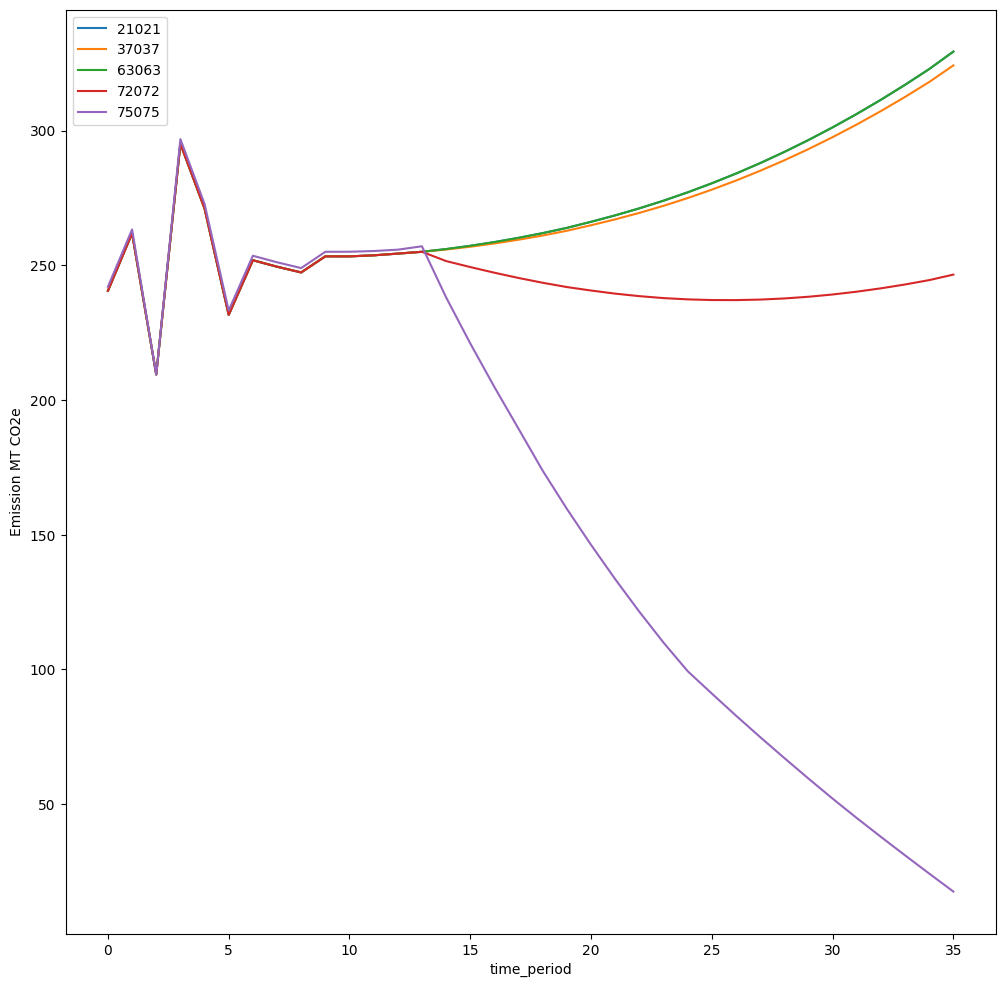

In [17]:
fig, ax = plt.subplots(figsize = (12, 12))
ax.set_xlabel(sisepuede.key_time_period)
ax.set_ylabel("Emission MT CO2e")
# 
all_primaries = sorted(list(df_out_region[sisepuede.key_primary].unique()))
dfg = df_out_region.groupby([sisepuede.key_primary])

for i, df_cur in dfg:

    if i[0] == 60060: continue
    
    y = np.array(df_cur[
        [x for x in df_out.columns if x.startswith("emission_co2e_subsector_")]
    ].sum(axis = 1)) 
    x = np.array(df_cur[sisepuede.key_time_period])
    
    ax.plot(x, y, label = i)
    

ax.legend()


##  Oops! Missing baseline
- Baseline strategy is always 0
- We can re-run sisepuede, and if we include and runs that have already been run, the db management system will avoid re-running those

In [18]:
# project across 2 futures for 1 design and, notably, *all* strategies (no filtering)
dict_filt = {
    "future_id": [0],
    "design_id": [0],
    "strategy_id": [0, 1020, 6002] 
}

primary_keys_out_2 = sisepuede(
    dict_filt,
    chunk_size = 2 # how often do we write to the output database
)

2026-03-11 12:04:52,980 - INFO - 
***	STARTING REGION costa_rica	***

2026-03-11 12:04:53,966 - INFO - Trying run primary_id = 0 in region costa_rica
2026-03-11 12:04:53,966 - INFO - Running AFOLU model
2026-03-11 12:04:54,161 - INFO - AFOLU model run successfully completed
2026-03-11 12:04:54,161 - INFO - Running CircularEconomy model
2026-03-11 12:04:54,182 - INFO - CircularEconomy model run successfully completed
2026-03-11 12:04:54,182 - INFO - Running IPPU model
2026-03-11 12:04:54,214 - INFO - IPPU model run successfully completed
2026-03-11 12:04:54,215 - INFO - Running Energy model (EnergyConsumption without Fugitive Emissions)
2026-03-11 12:04:54,223 - DEBUG - Missing elasticity information found in 'project_energy_consumption_by_fuel_from_effvars': using specified future demands.
2026-03-11 12:04:54,262 - INFO - EnergyConsumption without Fugitive Emissions model run successfully completed
2026-03-11 12:04:54,262 - INFO - Running Energy model (Electricity and Fuel Production: 

2026-11-Mar 12:04:55.097 Started modeling scenario. NEMO version = 2.2.0, solver = HiGHS.
2026-11-Mar 12:04:55.151 Started optimizing following years: [1000, 1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 1010, 1011, 1012].


2026-03-11 12:07:10,923 - INFO - NemoMod ran successfully with the following status: OPTIMAL
2026-03-11 12:07:10,929 - INFO - EnergyProduction model run successfully completed
2026-03-11 12:07:10,930 - INFO - Running Energy (Fugitive Emissions)
2026-03-11 12:07:10,947 - INFO - Fugitive Emissions from Energy model run successfully completed
2026-03-11 12:07:10,948 - INFO - Appending Socioeconomic outputs
2026-03-11 12:07:10,952 - INFO - Socioeconomic outputs successfully appended.
2026-03-11 12:07:10,954 - INFO - Model run for primary_id = 0 successfully completed in 136.99 seconds (n_tries = 1).
2026-03-11 12:07:10,961 - INFO - 
***	 REGION costa_rica COMPLETE	***

2026-03-11 12:07:11,019 - INFO - Table MODEL_OUTPUT successfully appended to /Users/dianamendez/sisepuede-env/lib/python3.11/site-packages/sisepuede/out/sisepuede_run_2026-03-11T11;53;04.046599/sisepuede_run_2026-03-11T11;53;04.046599_output_database/MODEL_OUTPUT.csv.
2026-03-11 12:07:11,021 - INFO - Table ATTRIBUTE_PRIMARY 

2026-11-Mar 12:05:19.828 Finished optimizing following years: [1000, 1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 1010, 1011, 1012].
2026-11-Mar 12:05:19.856 Started optimizing following years: [1013, 1014, 1015, 1016, 1017, 1018, 1019, 1020, 1021, 1022, 1023, 1024, 1025, 1026, 1027, 1028, 1029, 1030, 1031, 1032, 1033, 1034, 1035].
2026-11-Mar 12:07:10.840 Finished optimizing following years: [1013, 1014, 1015, 1016, 1017, 1018, 1019, 1020, 1021, 1022, 1023, 1024, 1025, 1026, 1027, 1028, 1029, 1030, 1031, 1032, 1033, 1034, 1035].
set ['emission_co2e_co2_entc_bmass_processing_and_refinement_fp_hydrogen_gasification'] = 0 in energy production. FIX WITH NEW fp_hydrogen_gasification_biomass TECH.


##  Have to read the output again

In [19]:
df_out = sisepuede.read_output(None)

# could query this, but our dataset is small enough to store in memory
df_out_region = (
    df_out[
        df_out[sisepuede.key_region].isin([_REGION_NAME])
    ]
    .reset_index(drop = True)
)

df_out_region

,primary_id,region,time_period,area_agrc_crops_bevs_and_spices,area_agrc_crops_cereals,area_agrc_crops_fibers,area_agrc_crops_fruits,area_agrc_crops_herbs_and_other_perennial_crops,area_agrc_crops_nuts,area_agrc_crops_other_annual,...,yield_agrc_fruits_tonne,yield_agrc_herbs_and_other_perennial_crops_tonne,yield_agrc_nuts_tonne,yield_agrc_other_annual_tonne,yield_agrc_other_woody_perennial_tonne,yield_agrc_pulses_tonne,yield_agrc_rice_tonne,yield_agrc_sugar_cane_tonne,yield_agrc_tubers_tonne,yield_agrc_vegetables_and_vines_tonne
0,21021,costa_rica,0,0.0,367983.831774,68239.857458,80.234375,79198.541655,6714.566582,1.154590e+06,...,1607.703461,955073.693482,19786.484805,7.132381e+06,0.0,985.642069,2.422231e+06,2.104457e+07,166526.651285,147.841681
1,21021,costa_rica,1,0.0,362096.267342,67148.052539,78.950664,77931.403057,6607.136744,1.136117e+06,...,1616.909034,977244.208052,22830.850901,8.141189e+06,0.0,1147.287929,2.270951e+06,2.014820e+07,170203.458526,150.239733
2,21021,costa_rica,2,0.0,360603.256374,66871.184789,78.625131,77610.072930,6579.893913,1.131433e+06,...,1572.095458,943834.205917,20014.830969,1.258079e+07,0.0,1387.559377,2.281962e+06,2.522074e+07,170020.494166,144.369498
3,21021,costa_rica,3,0.0,359180.755369,66607.392585,78.314972,77303.918161,6553.937670,1.126969e+06,...,1483.984815,950000.734264,22121.396585,6.126346e+06,0.0,1454.827115,2.421785e+06,2.532944e+07,161700.601978,147.613979
4,21021,costa_rica,4,0.0,358002.730124,66388.936588,78.058118,77050.380170,6532.442353,1.123273e+06,...,1579.787589,950624.475419,19546.265136,6.938924e+06,0.0,1122.623719,2.150882e+06,2.351716e+07,166345.161971,163.535551
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211,0,costa_rica,31,0.0,298101.577254,55280.714486,64.997404,64158.281275,5439.431616,9.353266e+05,...,1259.852108,771385.589699,16042.737273,5.911237e+06,0.0,989.839387,1.913757e+06,2.082277e+07,143481.822497,128.428515
212,0,costa_rica,32,0.0,296107.216700,54910.875194,64.562558,63729.049244,5403.040705,9.290691e+05,...,1251.423440,766224.862249,15935.408078,5.871690e+06,0.0,983.217159,1.900953e+06,2.068346e+07,142521.899743,127.569302
213,0,costa_rica,33,0.0,294127.716630,54543.791667,64.130952,63303.015530,5366.920953,9.228582e+05,...,1243.057575,761102.588687,15828.878620,5.832437e+06,0.0,976.644275,1.888245e+06,2.054519e+07,141569.129616,126.716491
214,0,costa_rica,34,0.0,292162.964546,54179.443045,63.702562,62880.155919,5331.070305,9.166936e+05,...,1234.754040,756018.477897,15723.142844,5.793477e+06,0.0,970.120361,1.875632e+06,2.040795e+07,140623.457968,125.870034


###  2. We can also see CO2e by subsector

###  Look at primary ids

In [20]:
primary_keys = primary_keys_out.get(_REGION_NAME)
sisepuede.odpt_primary.get_indexing_dataframe_from_primary_key(
    sorted(df_out[sisepuede.key_primary].unique())
)


,primary_id,design_id,strategy_id,future_id
0,0,0,0,0
1,21021,0,1020,0
2,37037,0,2012,0
3,63063,0,3025,0
4,72072,0,4006,0
5,75075,0,6002,0


In [21]:
?sisepuede.odpt_primary.get_key_value

Signature: sisepuede.odpt_primary.get_key_value(**kwargs) -> int
Docstring: Get the key value associated with an input set of dimensional values.
File:      ~/sisepuede-env/lib/python3.11/site-packages/sisepuede/data_management/ordered_direct_product_table.py
Type:      method

###  Examine baseline strategy

(<Figure size 1200x700 with 1 Axes>,
 <Axes: xlabel='time_period', ylabel='Emission MT CO2e'>)

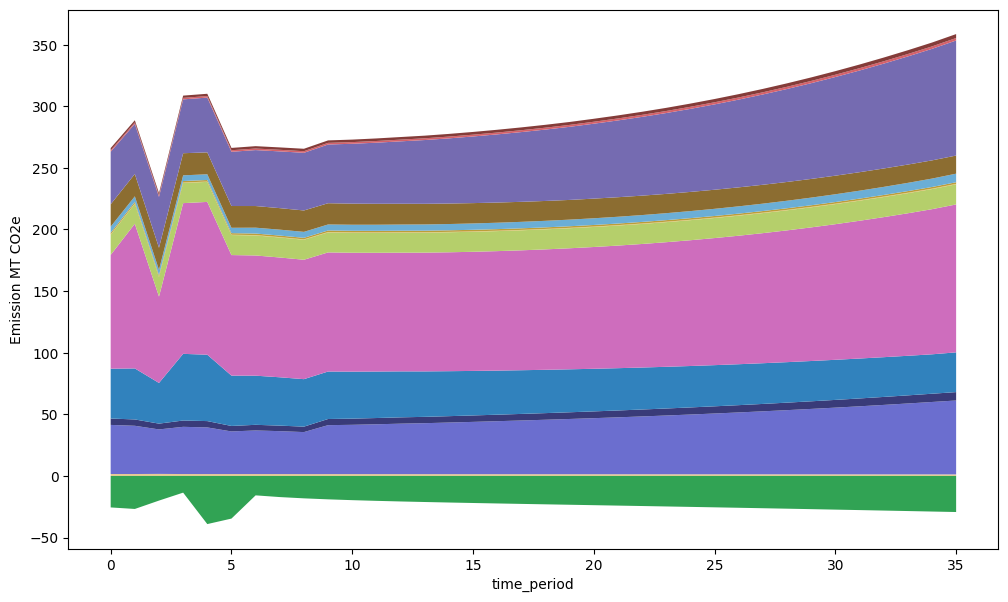

In [22]:
fig, ax = plt.subplots(figsize = (12, 7))
ax.set_xlabel(sisepuede.key_time_period)
ax.set_ylabel("Emission MT CO2e")

# get scenario key from dictionary
primary_id = sisepuede.odpt_primary.get_key_value(
    **{
        sisepuede.key_design: 0,
        sisepuede.key_future: 0,
        sisepuede.key_strategy: 1020,
    }
)
df_cur = df_out_region[df_out_region[sisepuede.key_primary].isin([primary_id])]

spp.plot_emissions_stack(
    df_cur,
    sisepuede.model_attributes,
    figtuple = (fig, ax),
    
)

#ax.legend()

## How about strategy 6002?

In [23]:
strategies.get_strategy(6002).name


'All Actions'

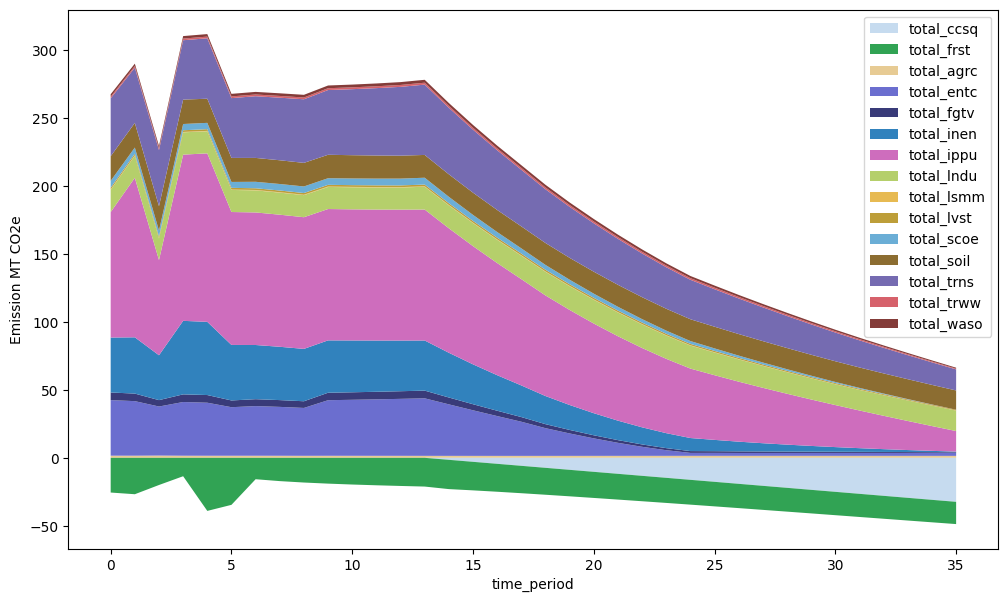

In [24]:
fig, ax = plt.subplots(figsize = (12, 7))
ax.set_xlabel(sisepuede.key_time_period)
ax.set_ylabel("Emission MT CO2e")

# get scenario key from dictionary
primary_id = sisepuede.odpt_primary.get_key_value(
    **{
        sisepuede.key_design: 0,
        sisepuede.key_future: 0,
        sisepuede.key_strategy: 6002,
    }
)
df_cur = df_out_region[df_out_region[sisepuede.key_primary].isin([primary_id])]

spp.plot_emissions_stack(
    df_cur,
    sisepuede.model_attributes,
    figtuple = (fig, ax), 
)

handles, labels = ax.get_legend_handles_labels()
labels = [l.replace("emission_co2e_subsector_", "") for l in labels]
ax.legend(handles, labels, loc="upper right")

###  3a. We can go further down and look at gas within subsector - CH4 emisions from Livestock Enteric Fermentation

In [25]:
# look for baseline
primary_id = sisepuede.odpt_primary.get_key_value(
    **{
        sisepuede.key_design: 0,
        sisepuede.key_future: 0,
        sisepuede.key_strategy: 1020
    }
)

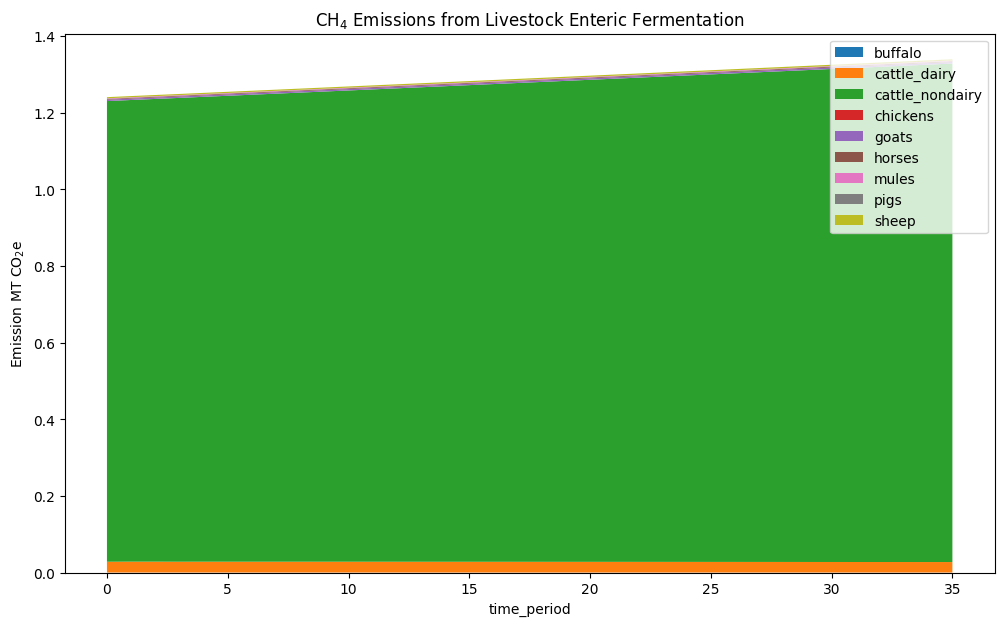

In [26]:
# variable to examine
modvar = sisepuede.model_attributes.get_variable(
    ":math:\\text{CH}_4 Emissions from Livestock Enteric Fermentation",
    #"Land Use Area"
)

df_cur = df_out_region[df_out_region[sisepuede.key_primary].isin([primary_id])]

fig, ax = plt.subplots(figsize = (12, 7))
ax.set_xlabel(sisepuede.key_time_period)
ax.set_ylabel("Emission MT $\mathrm{CO}_2$e")
# ax.set_title(modvar.name)
ax.set_title("$\mathrm{CH}_4$ Emissions from Livestock Enteric Fermentation")

sup.plot_stack(
    df_cur,
    modvar.fields,
    figtuple = (fig, ax, ),
)

handles, labels = ax.get_legend_handles_labels()
labels = [l.replace("emission_co2e_ch4_lvst_entferm_", "") for l in labels]
ax.legend(handles, labels, loc="upper right")

###  3b. HFCs and PFCs in IPPU

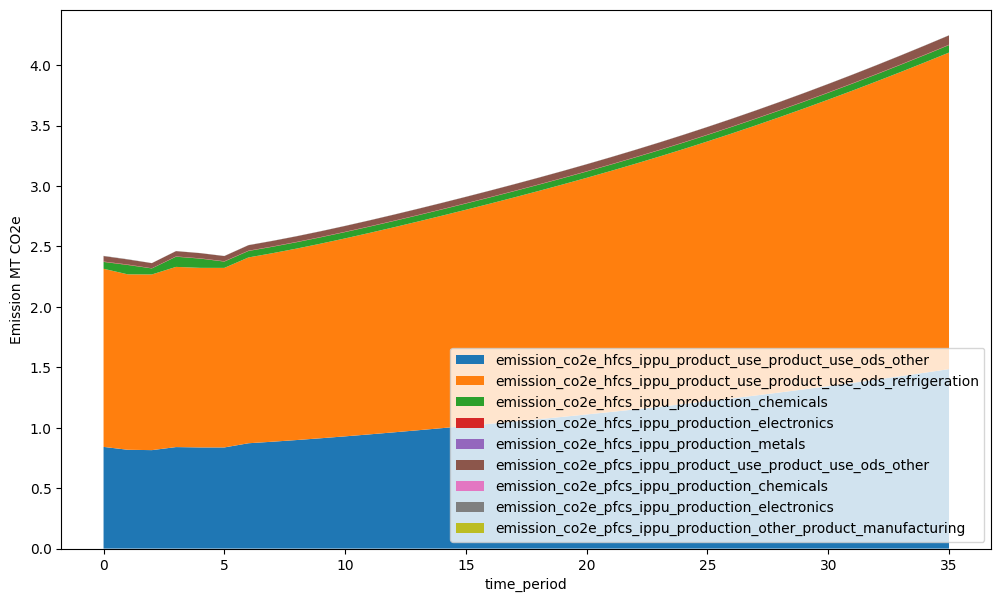

In [27]:
fig, ax = plt.subplots(figsize = (12, 7))
ax.set_xlabel(sisepuede.key_time_period)
ax.set_ylabel("Emission MT CO2e")


fields = [
    x for x in df_cur.columns 
    if x.startswith("emission_co2e_") and ("_ippu_" in x) and (("hfcs" in x) or ("pfcs" in x))
]


sup.plot_stack(
    df_cur,
    fields,
    figtuple = (fig, ax, ),
)

ax.legend()

###  4. The land use reallocation factor affects land use, imports, and exports

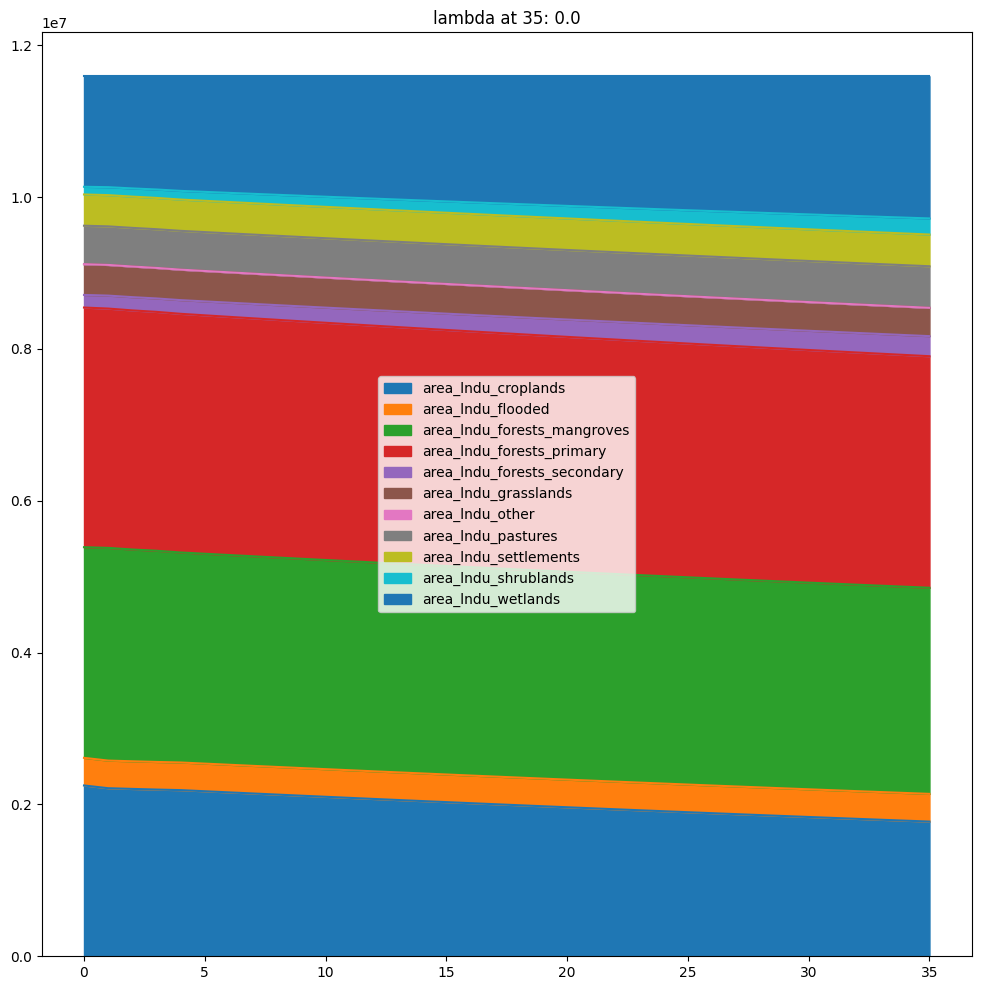

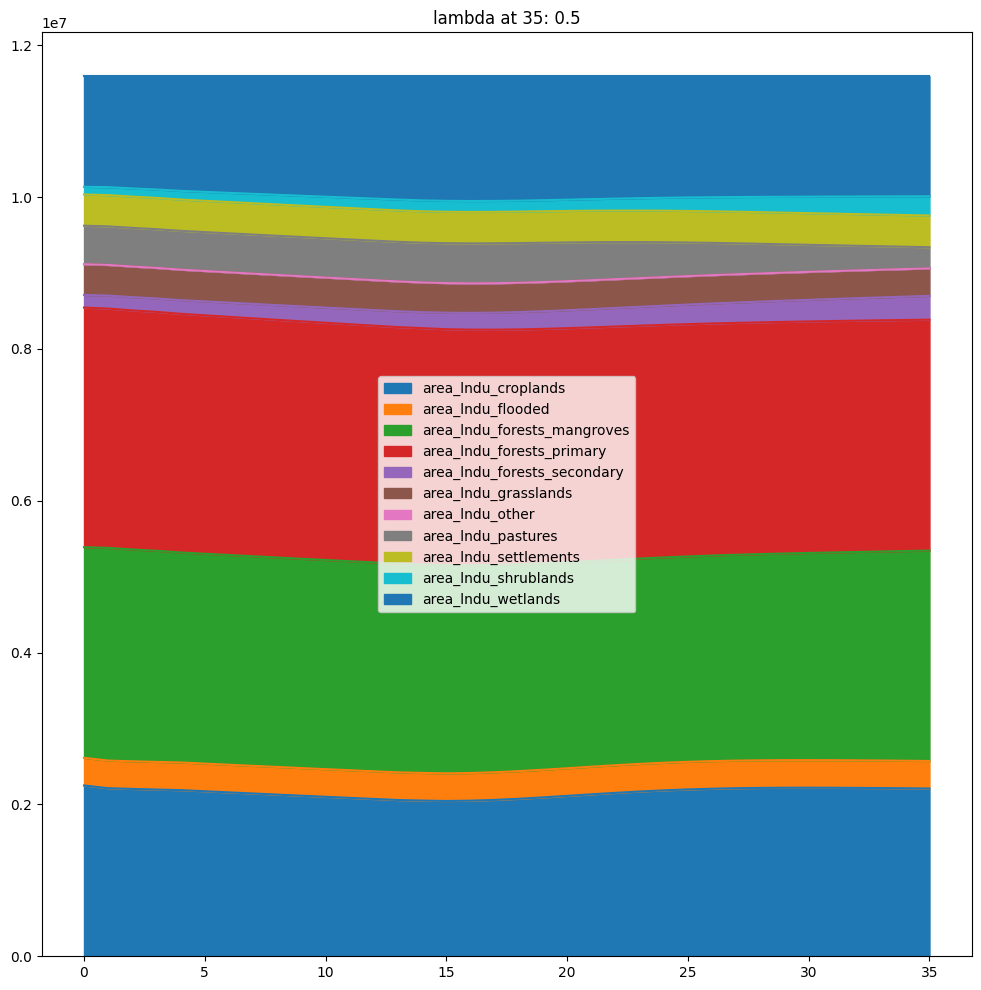

In [28]:
primary_keys = primary_keys_out.get(_REGION_NAME)  # extract the list first

for ind in [0, 4]:
    i = primary_keys[ind]
    fig, ax = plt.subplots(figsize = (12, 12))
    
    df_cur = df_out[df_out["primary_id"] == i]
    df_cur = sisepuede.model_attributes.extract_model_variable(df_cur, "Land Use Area", return_type = "data_frame")
    
    # val = sisepuede.generate_scenario_database_from_primary_key(i)["DEMO"]["lndu_reallocation_factor"].iloc[-1]
    val = sisepuede.generate_scenario_database_from_primary_key(i)[_REGION_NAME]["lndu_reallocation_factor"].iloc[-1]
    
    df_cur.plot.area(ax = ax)
    ax.set_title(f"lambda at 35: {val}")
    
    plt.show()
    
    

###  5. Database functionality streamlines parallelization and analysis

##  Suppose you want to generate a certain future using a primary id


In [29]:
p_id = sisepuede.odpt_primary.get_key_value(
    **{
        "design_id": 0,
        "future_id": 0,
        "strategy_id": 6002
    }
)

print(f"{sisepuede.key_primary} = {p_id}")

primary_id = 75075


# You can generate tables on the fly using primary ids
- e.g., say you want to see what the input associated with future_id 145, strategy 6002, design 0 looks like
- You could also feed `generate_scenario_database_from_primary_key` a dictionary of dimensional values

In [30]:
# create a dictionary of runs since different regions will have different dbs
dict_db = sisepuede.generate_scenario_database_from_primary_key(p_id);
df_pid = dict_db.get(_REGION_NAME)

# look at the dataframe
df_pid.head()

,primary_id,region,time_period,area_gnrl_country_ha,area_lndu_infimum_croplands_ha,area_lndu_infimum_flooded_ha,area_lndu_infimum_forests_mangroves_ha,area_lndu_infimum_forests_primary_ha,area_lndu_infimum_forests_secondary_ha,area_lndu_infimum_grasslands_ha,...,yf_agrc_herbs_and_other_perennial_crops_tonne_ha,yf_agrc_nuts_tonne_ha,yf_agrc_other_annual_tonne_ha,yf_agrc_other_woody_perennial_tonne_ha,yf_agrc_pulses_tonne_ha,yf_agrc_rice_tonne_ha,yf_agrc_sugar_cane_tonne_ha,yf_agrc_tubers_tonne_ha,yf_agrc_vegetables_and_vines_tonne_ha,yf_lndu_supremum_pastures_tonne_per_ha
0,75075,costa_rica,0,13565900.0,-999.0,-999.0,10000.0,10000.0,10000.0,-999.0,...,12.059233,2.946800,6.177415,0.0,2.755621,8.636027,73.140598,37.547100,28.821448,92.81
1,75075,costa_rica,1,13565900.0,-999.0,-999.0,10000.0,10000.0,10000.0,-999.0,...,12.539800,3.455483,7.165802,0.0,3.259699,8.228317,71.163825,39.000100,29.765171,92.81
2,75075,costa_rica,2,13565900.0,-999.0,-999.0,10000.0,10000.0,10000.0,-999.0,...,12.161233,3.041817,11.119348,0.0,3.958685,8.302446,89.448975,39.119475,28.720595,92.81
3,75075,costa_rica,3,13565900.0,-999.0,-999.0,10000.0,10000.0,10000.0,-999.0,...,12.289167,3.375283,5.436126,0.0,4.167037,8.846059,90.190264,37.352525,29.482348,92.81
4,75075,costa_rica,4,13565900.0,-999.0,-999.0,10000.0,10000.0,10000.0,-999.0,...,12.337700,2.992183,6.177415,0.0,3.226093,7.882382,84.012849,38.551850,32.769776,92.81


In [31]:
inds = sisepuede.database.db.dict_iterative_database_tables.get("MODEL_OUTPUT").available_indices
inds

{('costa_rica', 0),
 ('costa_rica', 21021),
 ('costa_rica', 37037),
 ('costa_rica', 63063),
 ('costa_rica', 72072),
 ('costa_rica', 75075)}

In [32]:
sisepuede.odpt_primary.get_indexing_dataframe_from_primary_key([x[1] for x in sorted(list(inds))])

,primary_id,design_id,strategy_id,future_id
0,0,0,0,0
1,21021,0,1020,0
2,37037,0,2012,0
3,63063,0,3025,0
4,72072,0,4006,0
5,75075,0,6002,0
